In [1]:
import os
import math
import time
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter
from problems.ThickenShell import ThickenShell
from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADDomainVisualizer import CADDomainVisualizer
from Utils.CADVisualizer   import CADVisualizer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell
from Training.MainTrain import NN_Trainer, TrainingConfig
from Decoder_CLasses.ContinuousVoronoiDecoder import ContinuousVoronoiDecoder
from Decoder_CLasses.NearUniformHoneycombBaseline import NearUniformHoneycombBaseline
from Decoder_CLasses.IntrinsicSurfaceHoneycombBaseline import IntrinsicSurfaceHoneycombBaseline
from Pred_NN_Classes.ppnet import PPNet
from scipy.spatial import Delaunay, Voronoi, voronoi_plot_2d, cKDTree,QhullError
from Utils.ExportAbaqus_VoxelBased import export_abaqus_voxel_fem
from Utils.ExportAbaqus import export_abaqus_shell
from Utils.embedded_centroid_stress_audit import (
    export_embedded_centroid_stress_audit,
    print_stress_case_summary,
)
from Utils.RunFEM_ExportVoxelABA import VoxelFEMAbaqusRunner

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)

%matplotlib inline
def random_seeds_min_dist(N, min_dist=0.08, seed=1, max_tries=10000, device="cpu"):
    torch.manual_seed(seed)

    seeds = []
    tries = 0

    while len(seeds) < N and tries < max_tries:
        p = torch.rand(2, device=device)

        if len(seeds) == 0:
            seeds.append(p)
        else:
            current = torch.stack(seeds, dim=0)
            d = torch.linalg.norm(current - p[None, :], dim=-1)

            if d.min() >= min_dist:
                seeds.append(p)

        tries += 1

    if len(seeds) < N:
        raise RuntimeError(
            f"Could only generate {len(seeds)} seeds with min_dist={min_dist}."
        )

    return torch.stack(seeds, dim=0)

Code Directory: /home/arash/HVD_SeedsBase
Test Step files Directory: /home/arash/HVD_SeedsBase/Testparts
device: cuda
PyVista backend: trame


In [4]:

def to_numpy(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def show_surface_density(fields, density_key="rho"):
    face_tensor = fields["face_tensor"]

    points = to_numpy(
        face_tensor["points_xyz"]
    ).astype(np.float64)

    triangles = to_numpy(
        face_tensor["faces_ijk"]
    ).astype(np.int64)

    # Convert one-based indexing if necessary.
    if triangles.min() == 1:
        triangles = triangles - 1

    # PyVista face format:
    # [3, i, j, k, 3, i, j, k, ...]
    pv_faces = np.column_stack(
        [
            np.full(triangles.shape[0], 3),
            triangles,
        ]
    ).reshape(-1)

    mesh = pv.PolyData(points, pv_faces)

    density = to_numpy(
        fields[density_key]
    ).reshape(-1)

    mesh.point_data["density"] = density

    plotter = pv.Plotter()
    plotter.add_mesh(
        mesh,
        scalars="density",
        cmap="viridis",
        clim=[0.0, 1.0],
        show_edges=False,
        scalar_bar_args={
            "title": density_key,
        },
    )

    plotter.add_text(
        f"Surface density: {density_key}",
        font_size=12,
    )

    plotter.show_axes()
    plotter.show()

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv


def show_fem_distributions(
    verification,
    *,
    case_name,
    stress_limit=None,
    bins=30,
    show_edges=False,
    output_dir="FEM_Maps",
    clim_stress=None,
    clim_displacement=None,
):
    fe = verification.embedded_fem.fe
    mesh = fe.mesh

    # Stress: maximum of 8 integration points per active element
    stress = (
        fe.stress_vm_ip_active
        .detach()
        .cpu()
        .numpy()
        .max(axis=1)
    )
    element_ids = np.asarray(mesh.active_element_ids, dtype=np.int64)

    # Displacement magnitude: one value per mesh node
    u = (
        fe.u.detach()
        .cpu()
        .numpy()
        .reshape(mesh.numNodes, 3)
    )
    displacement = np.linalg.norm(u, axis=1)
    active_node_ids = np.asarray(mesh.active_node_ids, dtype=np.int64)

    if len(stress) != len(element_ids):
        raise ValueError("Stress values do not match the active elements.")

    # Build a grid containing active C3D8 elements only
    connectivity = mesh.elemNodes[element_ids].astype(np.int64)
    cells = np.column_stack([
        np.full(len(element_ids), 8, dtype=np.int64),
        connectivity,
    ]).ravel()

    grid = pv.UnstructuredGrid(
        cells,
        np.full(len(element_ids), pv.CellType.HEXAHEDRON, dtype=np.uint8),
        np.asarray(mesh.nodeXYZ),
    )

    stress_name = "Max IP von Mises (MPa)"
    displacement_name = "Displacement magnitude (mm)"

    grid.cell_data[stress_name] = stress
    grid.point_data[displacement_name] = displacement
    surface = grid.extract_surface()

    # Two maps, with the same camera position
    plotter = pv.Plotter(shape=(1, 2), window_size=(1600, 700))

    Clim_stress_Def = None

    stress_range = (
        (0.0, float(stress.max()))
        if clim_stress is None
        else tuple(clim_stress)
    )

    displacement_range = (
        (0.0, float(displacement[active_node_ids].max()))
        if clim_displacement is None
        else tuple(clim_displacement)
    )

    plotter.subplot(0, 0)
    plotter.add_mesh(
        surface,
        scalars=stress_name,
        preference="cell",
        cmap="turbo",
        clim=stress_range,
        show_edges=show_edges,
        scalar_bar_args={"title": stress_name},
    )
    plotter.add_text(f"{case_name}: stress", font_size=11)
    plotter.add_axes()

    plotter.subplot(0, 1)
    plotter.add_mesh(
        surface,
        scalars=displacement_name,
        preference="point",
        cmap="viridis",
        clim=displacement_range,
        show_edges=show_edges,
        scalar_bar_args={"title": displacement_name},
    )
    plotter.add_text(f"{case_name}: displacement", font_size=11)
    plotter.add_axes()

    plotter.link_views()
    plotter.reset_camera()

    # Histograms: one count per active element and per active node
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].hist(stress, bins=bins)
    if stress_limit is not None:
        axes[0].axvline(
            stress_limit,
            color="red",
            linestyle="--",
            label=f"Limit: {stress_limit:g} MPa",
        )
        axes[0].legend()
    axes[0].set_xlabel(stress_name)
    axes[0].set_ylabel("Number of active elements")
    axes[0].set_title("Element stress distribution")

    axes[1].hist(displacement[active_node_ids], bins=bins)
    axes[1].set_xlabel(displacement_name)
    axes[1].set_ylabel("Number of active nodes")
    axes[1].set_title("Nodal displacement distribution")

    fig.suptitle(case_name)
    fig.tight_layout()

    # Save each model under its own name
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    grid.save(output_dir / f"{case_name}_fields.vtu")
    fig.savefig(output_dir / f"{case_name}_histograms.png", dpi=200)

    plotter.show(screenshot=str(output_dir / f"{case_name}_maps.png"))
    plt.show()

    worst_element_rank = int(np.argmax(stress))
    worst_node = int(active_node_ids[np.argmax(displacement[active_node_ids])])

    print(f"Maximum stress: {stress.max():.4f} MPa")
    print(f"  Element centre: {mesh.elemCenters[element_ids[worst_element_rank]]}")
    print(f"Maximum displacement: {displacement[worst_node]:.6f} mm")
    print(f"  Node position: {mesh.nodeXYZ[worst_node]}")

    if stress_limit is not None:
        above = int(np.count_nonzero(stress > stress_limit))
        print(
            f"Elements above {stress_limit:g} MPa: "
            f"{above}/{len(stress)} ({100 * above / len(stress):.2f}%)"
        )

    return grid

In [2]:
viz = CADVisualizer()
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Planar = TesPartsDir / "Planar.stp"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Helmet = TesPartsDir / "Helmet_New.stp"
FreeForm_Bend = TesPartsDir / "FreeForm_bend.stp"
CircBracket_Half = TesPartsDir / "CircBracket_Half.stp"
HelmetNew_Half = TesPartsDir / "HelmetNew_Half.stp"
Wing_NACA2412 = TesPartsDir / "Wing_NACA2412.stp"

aircraft_radome = TesPartsDir / "aircraft_radome.stp"

shape_path = Wing_NACA2412
Face_Cad = CADTensorGenerator(
    device=device,
    seed_domain_mask_res=512,
    mesh_size_scale = 0.2,
)

cad_domain, face_mesh = Face_Cad.generate_from_file(shape_path)
dx,dy,dz = Face_Cad.print_face_info();

points = face_mesh["points_xyz"].detach().cpu().numpy()
faces = face_mesh["pv_faces"].detach().cpu().numpy()

mesh = pv.PolyData(points, faces)

plotter = pv.Plotter()
plotter.add_mesh(
    mesh,
    show_edges=True,
)
plotter.add_axes()
plotter.show()

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    :  - Label 'Shapes/Document' (2D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 30%] Meshing curve 2 (BSpline)
Info    : [ 60%] Meshing curve 3 (BSpline)
Info    : [ 80%] Meshing curve 4 (BSpline)
Info    : Done meshing 1D (Wall 0.00880952s, CPU 0.008894s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (BSpline surface, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 2.2774s, CPU 2.25584s)
Info    : 85652 nodes 171306 elements
Info    : Clearing all models and views...
Info    : Done clearing all models and views

=== Active Face Info ===
XYZ bounds:
  X: [-0.000000, 20.000000]  span=20.000000
  Y: [-0.000000, 8.060202]  span=8.060202
  Z: [-0.000000, 1.549267]  span=1.549267

UV bounds:
  U: [-0.000000, 20.069717]
  V: [0.000000, 6.410034]

Periodic:
  U periodic: False
  V periodic: False



Widget(value='<iframe src="http://localhost:33479/index.html?ui=P_0x7cb7b68edd80_0&reconnect=auto" class="pyvi…

 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler


In [8]:
Strut_Thickness = 0.4
decoder = ContinuousVoronoiDecoder(
    Cad_domain=Face_Cad,
    face_mesh=face_mesh,
    n_seeds=100,
    strut_thickness=Strut_Thickness,
    seed_domain_margin=0.8,
    # Keep your other settings unchanged.
)
baseline = NearUniformHoneycombBaseline(
    decoder=decoder,
    cad_domain=Face_Cad,
    face_mesh=face_mesh,

    target_seed_count=None,
    spacing_uv=0.16,

    mode="uv_hex",
    relaxation_steps=0,
    relaxation_factor=0.5,

    include_exterior_support_sites=True,
    support_band_cells=2.5,

    relax_support_sites=True,
    support_relaxation_neighbors=6,
    max_relaxation_displacement_cells=0.75,
    preserve_lattice_topology=True,
)

honeycomb_fields = baseline.generate(
    device=device,
    dtype=torch.float64,
    generate_density_fiber=True,
)

curves_uv = honeycomb_fields["edge_curves_uv"]          # [E, K, 2]
curves_xyz = honeycomb_fields["edge_curves_xyz"]        # [E, K, 3]
graph = honeycomb_fields["graph"]
honeycomb_fields["rho"] = ( honeycomb_fields["rho"] > 0.5).to(dtype=honeycomb_fields["rho"].dtype,device=honeycomb_fields["rho"].device,)
total_all = honeycomb_fields["total_curve_length"]                 # scalar tensor
total_vd = honeycomb_fields["total_voronoi_curve_length"] 
print("total all curve length:", float(total_all))
print("total VD curve length:", float(total_vd))
show_surface_density(honeycomb_fields, density_key="rho")





total all curve length: 224.62693733827905
total VD curve length: 171.5176897251846


Widget(value='<iframe src="http://localhost:33479/index.html?ui=P_0x7cb22e598b50_4&reconnect=auto" class="pyvi…

In [37]:
voxel_size = float((dx + dy + dz) / 200.0)
thickness = 3.0 * voxel_size
print(f"dx:{dx} ,dy:{dy} ,dz:{dz}")
print(f"voxel size : {voxel_size}")
print(f"thickness : {thickness}")

dx:20.000000200000002 ,dy:8.060201691027869 ,dz:1.5492668252405302
voxel size : 0.148047343581342
thickness : 0.44414203074402603


In [38]:
common_settings = dict(
    thickness=thickness,
    voxel_size=voxel_size,
    extra_layers=1,
    tensors=face_mesh,

    voxelization_mode="triangle_distance",
    subvoxel_samples=1,
    min_geom_fraction=0.25,

    faces_index_base=0,
)

shell_problem = ThickenShell(
    **common_settings
)

In [39]:
shell_problem.show_boundaries(
    segments_per_curve=2
)

Widget(value='<iframe src="http://localhost:38183/index.html?ui=P_0x7de2a98b0c10_10&reconnect=auto" class="pyv…

In [8]:
# test_loads = [

#     {
#         "type": "force",
#         "boundaries": [5, 6, 7],
#         "magnitude": 50.0,
#         "direction": "-z",
#     },

#     {
#         "type": "distributed_force",
#         "boundaries": [17, 18, 19],
#         "magnitude": 100.0,
#         "direction": "y",
#         "distribution": "linear_decreasing",
#     },

#     {
#         "type": "moment",
#         "boundaries": [13, 14, 15],
#         "magnitude": 25.0,
#         "direction": "x",
#     },
# ]

In [44]:
Boundary_loads = [

    {
        "type": "force",
        "boundaries": [2,3],
        "magnitude": 1,
        "direction": "-z",
    },
    {
        "type": "distributed_force",
        "boundaries": [0,1],
        "magnitude": 5.0,
        "direction": "-y",
        "distribution": "parabolic",
    },
]

In [45]:
BC_Report = shell_problem.boundary_loading(
    fixed=[6,7],
    loads=Boundary_loads,
    band=0.05* voxel_size,
)

In [11]:
# Sueface_loads = [

    # # Axial force
    # {
    #     "type": "force",
    #     "axis": "x",
    #     "side": "max",
    #     "magnitude": 5.0,
    #     "direction": "x",
    # },

    # # Downward transverse force
    # {
    #     "type": "force",
    #     "axis": "x",
    #     "side": "max",
    #     "magnitude": 3.0,
    #     "direction": "-z",
    # },

    # Bending moment
    # {
    #     "type": "moment",
    #     "axis": "x",
    #     "side": "max",
    #     "magnitude": 20.0,
    #     "direction": "z",
    # },

    # # Torsional moment
    # {
    #     "type": "moment",
    #     "axis": "x",
    #     "side": "max",
    #     "magnitude": 50.0,
    #     "direction": "x",
    # },
# ]

In [12]:
# BC_Report = shell_problem.surface_loading(
#     fixed_axis="x",
#     fixed_side="min",

#     loads=Sueface_loads,

#     fixed_band=0.002 * voxel_size,
#     load_band=0.001 * voxel_size,
# )

In [9]:
voxel_size = float((dx + dy + dz) / 220.0)
thickness = 3.0 * voxel_size
print(f"dx:{dx} ,dy:{dy} ,dz:{dz}")
print(f"voxel size : {voxel_size}")
print(f"thickness : {thickness}")
LoadingCase ="ReaLCase"
common_settings = dict(
    thickness=thickness,
    voxel_size=voxel_size,
    extra_layers=1,
    tensors=face_mesh,

    voxelization_mode="triangle_distance",
    subvoxel_samples=1,
    min_geom_fraction=0.25,

    faces_index_base=0,
)

shell_problem = ThickenShell(
    **common_settings
)
Boundary_loads = [

    {
        "type": "force",
        "boundaries": [2,3],
        "magnitude": 1,
        "direction": "z",
    },
    {
        "type": "distributed_force",
        "boundaries": [0,1],
        "magnitude": 5.0,
        "direction": "y",
        "distribution": "parabolic",
    },
]

shell_problem.show_boundaries(
    segments_per_curve=2
)
BC_Report = shell_problem.boundary_loading(
    fixed=[6,7],
    loads=Boundary_loads,
    band=0.05* voxel_size,
)

dx:20.000000200000002 ,dy:8.060201691027869 ,dz:1.5492668252405302
voxel size : 0.13458849416485638
thickness : 0.4037654824945691


Widget(value='<iframe src="http://localhost:33479/index.html?ui=P_0x7cb46c337b80_5&reconnect=auto" class="pyvi…

In [10]:
loading_img = shell_problem.show_voxels_surface_and_bc(
    return_img=True,
    off_screen=True,
    window_size=(560, 430),
    show=True,
)

Widget(value='<iframe src="http://localhost:33479/index.html?ui=P_0x7cb22e5ff730_6&reconnect=auto" class="pyvi…

In [24]:

# LoadingCase = "tensile_compression"
# common_settings = dict(
#     thickness=thickness,
#     voxel_size=voxel_size,
#     extra_layers=1,
#     tensors=face_mesh,

#     voxelization_mode="triangle_distance",
#     subvoxel_samples=1,
#     min_geom_fraction=0.25,

#     bc_mapping_mode="surface_patch",
#     faces_index_base=0,
# )
# shell_problem = ThickenShell(
#     **common_settings,

#     load_case="fixed_side_loading",

#     # X identifies the two ends of the specimen.
#     BC_dir="x",

#     # Clamp the X-maximum end and load the X-minimum end.
#     fixed_side="min",
#     force_side="max",

#     # Apply the force along the global Z-axis.
#     load_dir="x",

#     # "max" means positive Z.
#     load_direction_side="max",

#     # Total applied force = +5 N.
#     Load_magnitude=0.000001,

#     # Select only outward-facing voxel faces at the X-maximum end.
#     fixed_region={
#         "extent_axis": "x",
#         "extent_side": "min",
#         "band": 0.001 * voxel_size,
#         "face_axis": "x",
#         "face_side": "min",
#     },

#     # Select only outward-facing voxel faces at the X-minimum end.
#     load_region={
#         "extent_axis": "x",
#         "extent_side": "max",
#         "band": 0.0005 * voxel_size,
#         "face_axis": "x",
#         "face_side": "max",
#         "direction": "z",
#         "total_force": -1,
#     },

# )
# loading_img = shell_problem.show_voxels_surface_and_bc(
#     return_img=True,
#     off_screen=True,
#     window_size=(560, 430),
#     show=True,
# )

In [11]:
verification = VoxelFEMAbaqusRunner(
    face_mesh=face_mesh,
    shell_problem=shell_problem,
    device=device,
    output_dir="FEM_Verification",
)
LoadingCase= "bend"

/home/arash/HVD_SeedsBase/neuraltomo_fem/FE.py:31: RuntimeWarning: Legacy material keys Ef/Et/nuf/nut are mapped to explicit orthotropic CCF fields. Prefer material_E1/E2/E3, material_nu12/nu23/nu13, and material_G12/G23/G13.
  self.H8 = H8_anisotropic_K(device, element_size=self.mesh.elemSize, **problem.materialProperty)



=== LL_TestWing_NACA2412-Honeycomb-bend_St4 ===
Maximum displacement magnitude: 1.80909180641 at [20.1209793091, 6.66213035583, 0.740236639977]
Compliance F^T U: 1.84654319286
Maximum raw IP von Mises stress: 517.227966309 at [-0.0388524532318, 5.88304138184, 0.577206194401]
Abaqus input: /home/arash/HVD_SeedsBase/FEM_Verification/LL_TestWing_NACA2412-Honeycomb-bend_St4.inp
Embedded mass: 0.04862497854 g
Above limit: 11
total all curve length: 224.62693733827905
total VD curve length: 171.5176897251846


Widget(value='<iframe src="http://localhost:33479/index.html?ui=P_0x7cb46c336230_7&reconnect=auto" class="pyvi…

/tmp/ipykernel_3290020/705670187.py:121: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface = grid.extract_surface()


Widget(value='<iframe src="http://localhost:33479/index.html?ui=P_0x7cb22e560580_8&reconnect=auto" class="pyvi…

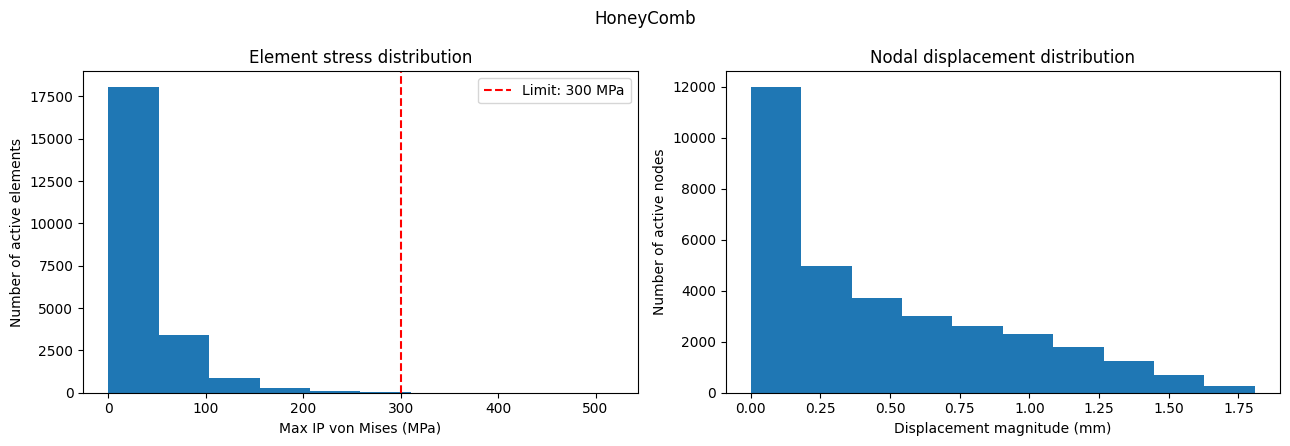

Maximum stress: 517.2280 MPa
  Element centre: [-1.00000000e-07  5.92189364e+00  5.38353877e-01]
Maximum displacement: 1.809092 mm
  Node position: [20.12097978  6.66213036  0.74023662]
Elements above 300 MPa: 11/22694 (0.05%)


In [12]:
#honeycomb_fields["rho"] = ( honeycomb_fields["rho"] > 0.5).to(dtype=honeycomb_fields["rho"].dtype,device=honeycomb_fields["rho"].device,)
optimized_metrics = verification.run_fields(
    fields=honeycomb_fields,
    case_name="LL_Test" + shape_path.stem + "-Honeycomb-" + LoadingCase + f"_St{str(Strut_Thickness)[2:]}",
    material_bins=2,
    material_mass_density_kg_m3=1550.0, 
)
edge_lengths = honeycomb_fields["edge_curve_lengths_xyz"]          # [E]
total_all = honeycomb_fields["total_curve_length"]                 # scalar tensor
total_vd = honeycomb_fields["total_voronoi_curve_length"]  
limit =300        # scalar tensor
stress = verification.embedded_fem.fe.stress_vm_ip_active.detach().cpu().numpy().max(axis=1)
print("Above limit:", np.count_nonzero(stress > limit))
print("total all curve length:", float(total_all))
print("total VD curve length:", float(total_vd))

show_surface_density(honeycomb_fields, density_key="rho")
grid = show_fem_distributions(
    verification,
    case_name="HoneyComb",
    stress_limit=300.0,
    bins=10,
    show_edges=True,
    #clim_stress=(0, 100),       # MPa
    #clim_displacement=(0, 0.5),  # mm
)


=== Wing_NACA2412-OptimizedModel_Bend_St0174_F5_V80_St025 ===
Maximum displacement magnitude: 1.57749056816 at [20.1209793091, 6.66213035583, 0.740236639977]
Compliance F^T U: 1.68079864979
Maximum raw IP von Mises stress: 401.130950928 at [5.69156885147, 0.364913016558, 0.230324551463]
Abaqus input: /home/arash/HVD_SeedsBase/FEM_Verification/Wing_NACA2412-OptimizedModel_Bend_St0174_F5_V80_St025.inp
Embedded mass: 0.0480426465779 g
Above limit: 9
total all curve length: 220.561767578125
total VD curve length: 167.45252990722656


Widget(value='<iframe src="http://localhost:33479/index.html?ui=P_0x7cb46c238df0_9&reconnect=auto" class="pyvi…

/tmp/ipykernel_3290020/705670187.py:121: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface = grid.extract_surface()


Widget(value='<iframe src="http://localhost:33479/index.html?ui=P_0x7cb46c367af0_10&reconnect=auto" class="pyv…

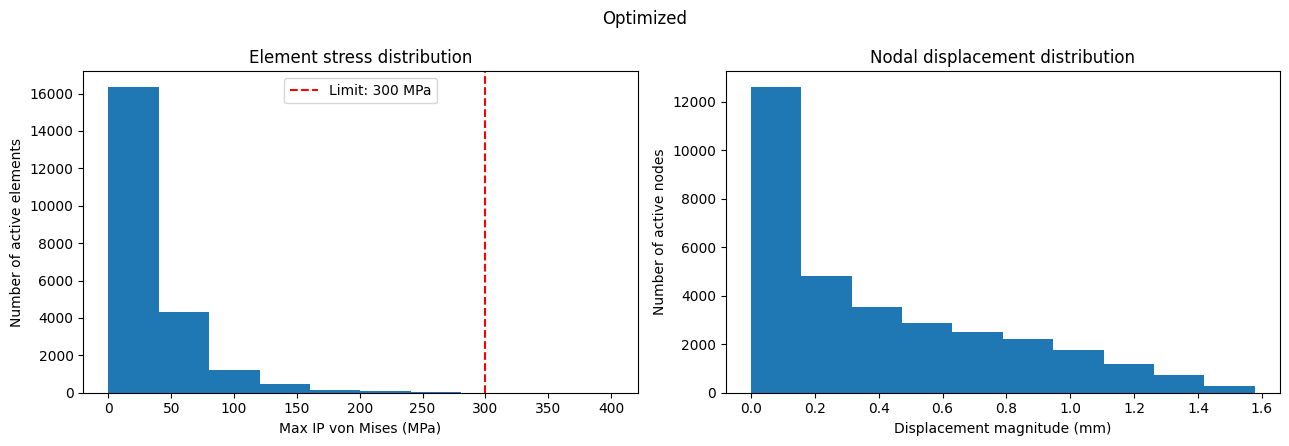

Maximum stress: 401.1310 MPa
  Element centre: [5.65271665 0.40376538 0.26917689]
Maximum displacement: 1.577491 mm
  Node position: [20.12097978  6.66213036  0.74023662]
Elements above 300 MPa: 9/22694 (0.04%)


In [13]:
from Training.MainTrain import (
    _field_to_numpy,
    load_optimized_shell_function,
    evaluate_optimized_shell_function,
    visualize_optimized_shell_fields,
)

Path1 = "/home/arash/HVD_SeedsBase/Case_Studies/Wing_NACA2412_50_Sth4_ReaLCase/optimized_shell_function.pt"
path2 = "/home/arash/HVD_SeedsBase/Case_Studies/PlanarPlannar_Seeds-70_Sth033/BestFeasibleCheckpoint/optimized_shell_function.pt"

Mpath =Path1
if not os.path.exists(Mpath):
    raise FileNotFoundError(f"Optimized shell function file not found: {Mpath}")
opt_fn = load_optimized_shell_function(Mpath, device="cpu")
fields = evaluate_optimized_shell_function(opt_fn)
fields["rho"] = (fields["rho"]>0.5).to(torch.float64)
optimized_metrics = verification.run_fields(
    fields=fields,
    case_name=shape_path.stem + "-OptimizedModel_Bend_St0174_F5_V80_St025",
    material_bins=2,
    material_mass_density_kg_m3=1550.0, 
)

total_all = fields["total_curve_length"]                 # scalar tensor
total_vd = fields["total_voronoi_curve_length"]
stress = verification.embedded_fem.fe.stress_vm_ip_active.detach().cpu().numpy().max(axis=1)
print("Above limit:", np.count_nonzero(stress > limit)) 
print("total all curve length:", float(total_all))
print("total VD curve length:", float(total_vd))
show_surface_density(fields, density_key="rho")
grid = show_fem_distributions(
    verification,
    case_name="Optimized",
    stress_limit=300.0,
    bins=10,
    show_edges=True,
    #clim_stress=(0, 100),       # MPa
    #clim_displacement=(0, 0.5),  # mm
)

In [14]:
%load_ext tensorboard
%tensorboard --logdir runs